<h1 style='text-align: center; font-family: Colonna MT; font-size: 25px; font-weight: 600'>SOIL TEXTURES CLASSIFICATION WITH MACHINE LEARNING<br>
<span style="text-align:center; font-family:Arial, sans-serif; font-size:16px; color:#555;">
    <strong>Chausiku Kassimu</strong>
    | data Scientist | Machine Learning Enthusiast | Python Developer<br>
    📧 <a href="mailto:chausikukassimu1@gmail.com">chausikukassimu1@gmail.com</a> | 💢 
</span>
</h1>

----

<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>1.0. IMPORT REQUIRED LIBRARIES</h1>

In [99]:
    # ── Data Manipulation and Visualizations Libraries
    from typing import List, Union, Optional
    import matplotlib.pyplot as plt
    from pandas.api.types import *
    import seaborn as sns
    import pandas as pd
    import numpy as np
    import math
    import warnings

    # ── Scientific Computiong and Statistics Libraries
    from scipy.stats import norm, jarque_bera
    from scipy.stats import skew, kurtosis
    from scipy.stats import pearsonr
    from scipy import stats
    
    # ── Machine Learning Models from Scikit Learn
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.svm import SVC
    from sklearn.ensemble import (
        RandomForestClassifier,
        GradientBoostingClassifier,
        ExtraTreesClassifier
        )

     # ── Features Preprocessing and Model Evaluations
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.preprocessing import LabelEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline

    from sklearn.preprocessing import label_binarize
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import (
        classification_report,
        confusion_matrix,
        accuracy_score,
        precision_score,
        recall_score,
        roc_auc_score,
        f1_score,
        roc_curve, 
        auc
        )

    # ── Miscellaneous
    plt.rcParams.update({'font.size': 10 })
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    pd.set_option('display.max_columns', 15)
    warnings.simplefilter("ignore")
    
    plt.rcParams['font.family']  =  "Arial" 
    plt.rcParams['figure.dpi']   =  100 
    plt.rcParams['font.size'] =  10 

    print("\n[1/1] Libraries Imported Successfully\n")


[1/1] Libraries Imported Successfully



<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>2.0. IMPORT AND INSPECTING DATASETS </h1>

In [97]:
FILEPATH = "./Datasets/Soil Health Dataset.csv"
df = pd.read_csv(FILEPATH)
display(df.sample(10))

,Soil pH,Organic Carbon (%),Total Nitrogen (%),Available Phosphorus (ppm),Exchangeable Potassium (cmol/kg),Cation Exchange Capacity (cmol/kg),Soil Moisture (%),Bulk Density (g/cm³),Electrical Conductivity (dS/m),Soil Respiration CO₂ (mg/kg/day),Soil Texture
181,6.96,1.82,0.19,4.91,0.52,19.36,35.11,1.43,0.68,86.91,Clay Loam
103,6.95,1.68,0.12,23.31,0.59,19.30,18.76,1.34,0.25,79.03,Clay Loam
225,6.47,1.33,0.14,10.79,0.48,16.30,40.71,1.29,0.08,57.61,Silty Clay
191,6.97,2.00,0.10,13.06,0.60,4.60,30.03,1.24,0.20,65.68,Clay Loam
112,6.74,2.53,0.16,13.85,0.55,6.70,32.92,1.30,0.11,71.23,Clay Loam
150,6.75,2.70,0.17,10.08,0.70,33.05,32.04,1.24,0.09,55.90,Clay Loam
317,4.98,5.12,0.28,8.62,0.45,4.40,60.35,0.82,0.22,62.17,Peat Soil
172,7.40,1.82,0.16,22.22,0.49,17.69,22.05,0.95,0.15,70.84,Clay Loam
251,5.91,0.81,0.18,10.05,0.73,37.18,26.25,1.49,1.55,63.33,Silty Clay
314,4.81,5.68,0.27,8.21,0.43,15.38,49.68,0.91,0.07,64.66,Peat Soil


<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'> 3.0: DATA OVERVIEW AND QUALITY CHECKS</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.1: DATA SHAPE AND COLUMNS</h3>

In [12]:
df.shape

(400, 11)

In [13]:
df.columns

Index(['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
       'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
       'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
       'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
       'Soil Respiration CO₂ (mg/kg/day)', 'Soil Texture'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Soil pH                             400 non-null    float64
 1   Organic Carbon (%)                  400 non-null    float64
 2   Total Nitrogen (%)                  400 non-null    float64
 3   Available Phosphorus (ppm)          400 non-null    float64
 4   Exchangeable Potassium (cmol/kg)    400 non-null    float64
 5   Cation Exchange Capacity (cmol/kg)  400 non-null    float64
 6   Soil Moisture (%)                   400 non-null    float64
 7   Bulk Density (g/cm³)                400 non-null    float64
 8   Electrical Conductivity (dS/m)      400 non-null    float64
 9   Soil Respiration CO₂ (mg/kg/day)    400 non-null    float64
 10  Soil Texture                        400 non-null    object 
dtypes: float64(10), object(1)
memory usage: 34.5+

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.2: COLUMNS PROFILINGS</h3>

In [17]:
def _column_audit(df: pd.DataFrame) -> pd.DataFrame:
    report = []
    for col_name in df.columns:
        col_dtype               = df[col_name].dtype
        num_of_nulls            = df[col_name].isnull().sum()
        num_of_non_nulls        = df[col_name].notnull().sum()
        num_of_distinct_values  = df[col_name].nunique()
        
        if num_of_distinct_values <= 10:
            distinct_values_counts = df[col_name].value_counts().to_dict()
        else:
            top_10_values_counts = df[col_name].value_counts().head(10).to_dict()
            distinct_values_counts = ({k: v for k, v in sorted(top_10_values_counts.items(),
                                        key=lambda item: item[1],
                                        reverse=True)}
                                         )

        report.append({
            'col_name':                  col_name,
            'col_dtype':                 col_dtype,
            'num_of_nulls':              num_of_nulls,
            'num_of_non_nulls':          num_of_non_nulls,
            'num_of_distinct_values':    num_of_distinct_values,
            'distinct_values_counts':    distinct_values_counts
        })
    
    return pd.DataFrame(report)

_column_audit(df)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,Soil pH,float64,0,400,400,"{4.588581469316734: 1, 4.971601883490142: 1, 5..."
1,Organic Carbon (%),float64,0,400,400,"{4.919684440237253: 1, 4.22859839087855: 1, 4...."
2,Total Nitrogen (%),float64,0,400,400,"{0.2842880609168573: 1, 0.2960359023329535: 1,..."
3,Available Phosphorus (ppm),float64,0,400,400,"{2.3581247361722246: 1, 15.75541746230509: 1, ..."
4,Exchangeable Potassium (cmol/kg),float64,0,400,400,"{0.5232871307740251: 1, 0.4762264922961615: 1,..."
5,Cation Exchange Capacity (cmol/kg),float64,0,400,400,"{19.58776723609973: 1, 20.90363822201643: 1, 2..."
6,Soil Moisture (%),float64,0,400,400,"{61.38395639689789: 1, 55.6760411655429: 1, 56..."
7,Bulk Density (g/cm³),float64,0,400,400,"{0.923855495377374: 1, 0.8551457163472139: 1, ..."
8,Electrical Conductivity (dS/m),float64,0,400,400,"{0.2120236722247101: 1, 0.09440950729242: 1, 0..."
9,Soil Respiration CO₂ (mg/kg/day),float64,0,400,400,"{129.78109833405725: 1, 87.82712610634938: 1, ..."


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.3: DUPLICATES RECORDS</h3>

In [19]:
df.duplicated().sum()

np.int64(0)

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.4: DTYPES VALIDATIONS</h3>

In [20]:
TYPE_CHECKS = {
    "numeric":   lambda x: isinstance(x,(int, float, np.integer, np.floating, np.number,)),
    "boolean":   lambda x: isinstance(x, (bool, np.bool_)),
    "string":    lambda x: isinstance(x, str),
    "datetime":  lambda x: isinstance(x, (pd.Timestamp, np.datetime64,),),
    "timedelta": lambda x: isinstance(x, (pd.Timedelta, np.timedelta64,),),
    "category":  lambda x: isinstance(x, pd.Categorical),
    "complex":   lambda x: isinstance(x, (complex, np.complexfloating)),
    "bytes":     lambda x: isinstance(x, bytes),
    "period":    lambda x: isinstance(x, pd.Period),
    "interval":  lambda x: isinstance(x, pd.Interval),
    }

def validations(df, decimals=2):
    reports = {}
    
    for col, s in df.items():
        s_nonnull   = s.dropna()
        result      = {name: ( s_nonnull.map(func).mean() * 100 if not s_nonnull.empty else 0) for name, func in TYPE_CHECKS.items()}
        result["Missing"] = s.isna().mean() * 100
        detected = [k for k, v in result.items() if k != "Missing" and v > 0 ]
        result["column_dtype"] = str(s.dtype)
        result["detected"] = (
            detected[0]
            if len(detected) == 1
            else "Mixed"
            if len(detected) > 1
            else "Unknown"
            )

        reports[col] = result

    report    = (pd.DataFrame(reports).T.fillna(0))
    pct_cols  = report.columns.difference(["column_dtype", "detected"])
    report[pct_cols] = (
        report[pct_cols]
        .astype(float)
        .round(decimals)
        .astype(str)
        .add("%")
        )

    return report

report = validations(df)
display(report)

,numeric,boolean,string,datetime,timedelta,category,complex,bytes,period,interval,Missing,column_dtype,detected
Soil pH,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Organic Carbon (%),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Total Nitrogen (%),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Available Phosphorus (ppm),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Exchangeable Potassium (cmol/kg),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Cation Exchange Capacity (cmol/kg),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Soil Moisture (%),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Bulk Density (g/cm³),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Electrical Conductivity (dS/m),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric
Soil Respiration CO₂ (mg/kg/day),100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,float64,numeric


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.5: OUTLIERS PROFULLING USING BOXPLOTS</h3>

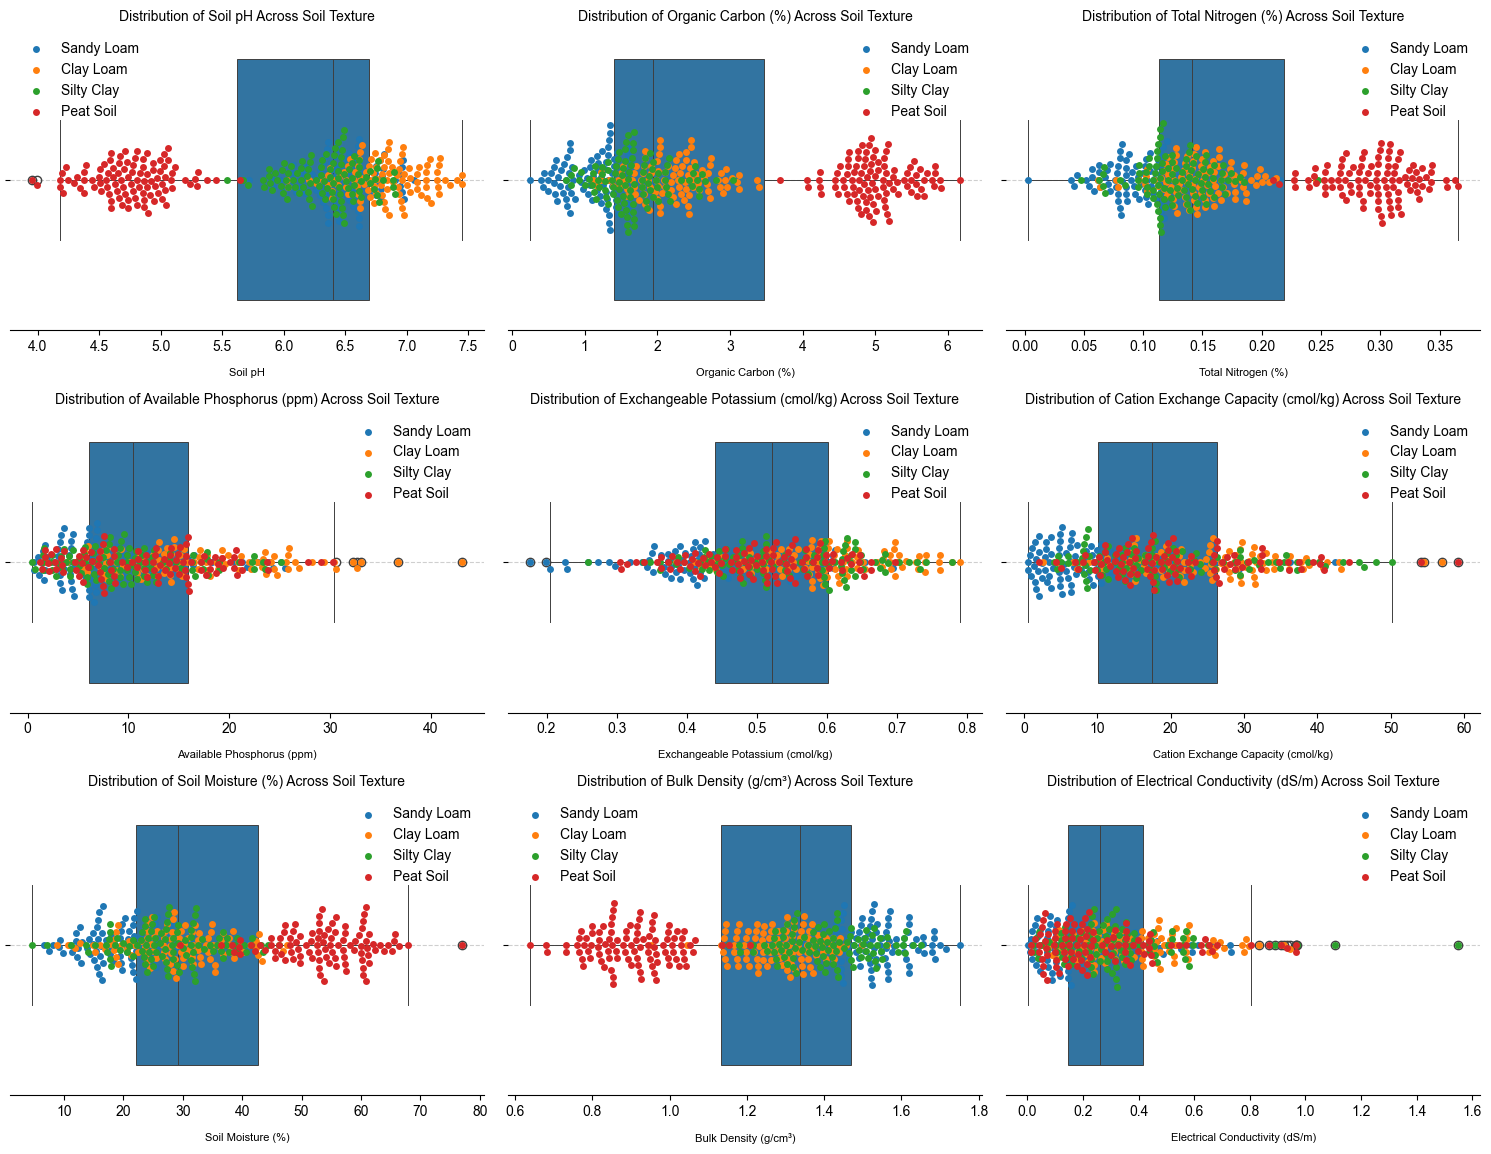

In [21]:
def boxplots(df: pd.DataFrame, variables: List[str], group: Optional[str] = None) -> None:
    num_variables = len(variables)
    cols = min(3, num_variables)
    rows = math.ceil(num_variables / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.atleast_1d(axes).ravel()
    
    for idx, column in enumerate(variables):
        sns.boxplot(x=df[column], ax=axes[idx], linewidth=0.7)
        
        if group and group in df.columns:
            groups = df[group].dropna().unique()
            palette = sns.color_palette("tab10", len(groups))
            for color, g in zip(palette, groups):
                data = df.loc[df[group] == g, column].dropna()
                if len(data) > 0:
                    sns.swarmplot(
                        x =data, 
                        ax = axes[idx], 
                        color= color, 
                        label = f'{str(g)}'
                    )

        axes[idx].spines[['left', 'right', 'top']].set_visible(False)
        axes[idx].set_title(f"Distribution of {column}" + (f" Across {group}" if group else ""), fontsize=10)
        axes[idx].set_xlabel(column, size=8, labelpad=10)
        axes[idx].grid(linestyle="--", alpha=0.6, axis="y")
        axes[idx].legend(frameon=False, loc="best")
        
    for idx in range(num_variables, len(axes)): fig.delaxes(axes[idx])
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    
    return fig
    
variables = ['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
   'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
   'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
   'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
   'Soil Respiration CO₂ (mg/kg/day)'][:-1]

fig = boxplots(df, variables, group='Soil Texture')

<h1 style='font-family: Bradley Hand ITC; font-size: 25px;  font-weight: 600''>4.0: DATASETS STATISTICS DESCRIPTIONS</h1>

<h4 style='font-family: Bradley Hand ITC; font-size: 18px;  font-weight: 600''>4.1: OVERALL STATISTIC DESCRIPTIONS</h4>

In [23]:
results = df.describe().T
display(results)

,count,mean,std,min,25%,50%,75%,max
Soil pH,400.00,6.10,0.85,3.95,5.62,6.40,6.69,7.45
Organic Carbon (%),400.00,2.52,1.55,0.24,1.40,1.93,3.47,6.17
Total Nitrogen (%),400.00,0.17,0.08,0.00,0.11,0.14,0.22,0.37
Available Phosphorus (ppm),400.00,11.67,7.31,0.40,6.10,10.45,15.90,43.15
Exchangeable Potassium (cmol/kg),400.00,0.52,0.11,0.18,0.44,0.52,0.60,0.79
Cation Exchange Capacity (cmol/kg),400.00,18.90,11.47,0.51,10.07,17.51,26.37,59.23
Soil Moisture (%),400.00,32.90,14.67,4.56,22.11,29.22,42.67,77.04
Bulk Density (g/cm³),400.00,1.28,0.25,0.64,1.13,1.34,1.47,1.75
Electrical Conductivity (dS/m),400.00,0.30,0.22,0.00,0.15,0.26,0.41,1.55
Soil Respiration CO₂ (mg/kg/day),400.00,48.17,30.59,2.86,26.47,42.04,63.82,206.51


In [24]:
results = df.describe(include='all').transpose()
display(results.fillna("-"))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Soil pH,400.00,-,-,-,6.10,0.85,3.95,5.62,6.40,6.69,7.45
Organic Carbon (%),400.00,-,-,-,2.52,1.55,0.24,1.40,1.93,3.47,6.17
Total Nitrogen (%),400.00,-,-,-,0.17,0.08,0.00,0.11,0.14,0.22,0.37
Available Phosphorus (ppm),400.00,-,-,-,11.67,7.31,0.40,6.10,10.45,15.90,43.15
Exchangeable Potassium (cmol/kg),400.00,-,-,-,0.52,0.11,0.18,0.44,0.52,0.60,0.79
Cation Exchange Capacity (cmol/kg),400.00,-,-,-,18.90,11.47,0.51,10.07,17.51,26.37,59.23
Soil Moisture (%),400.00,-,-,-,32.90,14.67,4.56,22.11,29.22,42.67,77.04
Bulk Density (g/cm³),400.00,-,-,-,1.28,0.25,0.64,1.13,1.34,1.47,1.75
Electrical Conductivity (dS/m),400.00,-,-,-,0.30,0.22,0.00,0.15,0.26,0.41,1.55
Soil Respiration CO₂ (mg/kg/day),400.00,-,-,-,48.17,30.59,2.86,26.47,42.04,63.82,206.51


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.2: CONTINUOUS VARIABLES STATISTIC DESCRIPTIONS</h4>

In [25]:
def _statistics(df: pd.DataFrame, variables: Optional[List[str]] = None, group: Optional[str] = None) -> pd.DataFrame:
    grouped  = df.groupby(group) if group else [(None, df)]
    results  = []
    
    for variable in variables:
        for name, df in grouped:
            counts        =  df[variable].count()
            mean_val      =  df[variable].mean()
            median_val    =  df[variable].median()
            mode_val      =  df[variable].mode().iloc[0] if not df[variable].mode().empty else np.nan
            std_dev       =  df[variable].std()
            variance      =  df[variable].var()
            value_range   =  df[variable].max() - df[variable].min()
            iqr           =  df[variable].quantile(0.75) - df[variable].quantile(0.25)
            
            skewness_val  =  skew(df[variable], nan_policy='omit')
            kurtosis_val  =  kurtosis(df[variable], nan_policy='omit')
            jb_stat, jb_p =  jarque_bera(df[variable])
            jb_p_interp   =  'Non-Normal' if jb_p < 0.05 else 'Normal'
            jb_p_fmt      =  f'<0.05' if jb_p < 0.05 else f'{jb_p:.3f}'
    
            results.append({
                'Variables':       variable,
                group if group else 'None': name,
                'Counts':       counts,
                'Mean':         mean_val,
                'Median':       median_val,
                'Mode':         mode_val,
                'Std':          std_dev,
                'Variance':     variance,
                'Range':        value_range,
                'IQR':          iqr,
                'Skewness':     skewness_val,
                'Kurtosis':     kurtosis_val,
                'JB p-value':   jb_p_fmt,
                'JB Notes':     jb_p_interp,
            })
    results = pd.DataFrame(results)
    results = results.drop(columns=['None']) if group is None else results
    return results

variables = df.select_dtypes(include=[np.number]).columns
results    = _statistics(df, variables)
display(results)

,Variables,Counts,Mean,Median,Mode,Std,Variance,Range,IQR,Skewness,Kurtosis,JB p-value,JB Notes
0,Soil pH,400,6.10,6.40,3.95,0.85,0.72,3.50,1.07,-0.84,-0.55,<0.05,Non-Normal
1,Organic Carbon (%),400,2.52,1.93,0.24,1.55,2.41,5.93,2.07,0.83,-0.71,<0.05,Non-Normal
2,Total Nitrogen (%),400,0.17,0.14,0.00,0.08,0.01,0.36,0.11,0.79,-0.54,<0.05,Non-Normal
3,Available Phosphorus (ppm),400,11.67,10.45,0.40,7.31,53.38,42.75,9.80,0.87,0.68,<0.05,Non-Normal
4,Exchangeable Potassium (cmol/kg),400,0.52,0.52,0.18,0.11,0.01,0.61,0.16,-0.12,-0.20,0.433,Normal
5,Cation Exchange Capacity (cmol/kg),400,18.90,17.51,0.51,11.47,131.51,58.72,16.30,0.67,0.13,<0.05,Non-Normal
6,Soil Moisture (%),400,32.90,29.22,4.56,14.67,215.17,72.48,20.56,0.57,-0.54,<0.05,Non-Normal
7,Bulk Density (g/cm³),400,1.28,1.34,0.64,0.25,0.06,1.12,0.34,-0.57,-0.69,<0.05,Non-Normal
8,Electrical Conductivity (dS/m),400,0.30,0.26,0.00,0.22,0.05,1.55,0.27,1.35,3.02,<0.05,Non-Normal
9,Soil Respiration CO₂ (mg/kg/day),400,48.17,42.04,2.86,30.59,935.71,203.65,37.35,1.31,2.77,<0.05,Non-Normal


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.3: CONTINUOUS VARIABLES GROUPED STATISTICS</h4>

In [26]:
grouped_stats    = _statistics(df, variables, group="Soil Texture")
display(grouped_stats)

,Variables,Soil Texture,Counts,Mean,Median,Mode,Std,Variance,Range,IQR,Skewness,Kurtosis,JB p-value,JB Notes
0,Soil pH,Clay Loam,100,6.81,6.82,6.02,0.31,0.09,1.43,0.40,-0.14,-0.28,0.721,Normal
1,Soil pH,Peat Soil,100,4.75,4.77,3.95,0.31,0.10,1.70,0.38,-0.07,0.21,0.882,Normal
2,Soil pH,Sandy Loam,100,6.47,6.46,5.71,0.27,0.07,1.34,0.30,-0.18,-0.16,0.736,Normal
3,Soil pH,Silty Clay,100,6.34,6.40,5.54,0.29,0.09,1.36,0.41,-0.31,-0.35,0.341,Normal
4,Organic Carbon (%),Clay Loam,100,2.20,2.20,1.12,0.50,0.25,2.28,0.67,0.11,-0.41,0.642,Normal
5,Organic Carbon (%),Peat Soil,100,5.01,4.96,3.68,0.45,0.21,2.49,0.51,0.06,0.13,0.939,Normal
6,Organic Carbon (%),Sandy Loam,100,1.21,1.24,0.24,0.48,0.23,2.32,0.67,0.38,-0.03,0.297,Normal
7,Organic Carbon (%),Silty Clay,100,1.68,1.62,0.74,0.47,0.22,2.31,0.55,0.50,0.12,0.123,Normal
8,Total Nitrogen (%),Clay Loam,100,0.15,0.15,0.06,0.03,0.00,0.18,0.04,-0.02,0.57,0.512,Normal
9,Total Nitrogen (%),Peat Soil,100,0.29,0.30,0.21,0.03,0.00,0.16,0.04,-0.28,-0.26,0.445,Normal


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.4: CONTINUOUS VARIABLES GROUPED STATISTICS | MEAN COMPARISONS</h4>

In [27]:
def grouped_statistiks(df: pd.DataFrame, variables: List[str], group: str) -> pd.DataFrame:
    variables   =  variables.remove(group) if group in variables else variables
    ungrouped   =  df.drop(columns=[group])
    grand_mean  =  ungrouped[variables].mean()
    
    sem      = ungrouped[variables].sem()
    cv       = ungrouped[variables].std() / ungrouped[variables].mean() * 100
    grouped  = df.groupby(group)[variables].agg(['mean', 'sem']).reset_index()
    
    results = pd.DataFrame()
    for variable in variables:
        results[variable] = grouped.apply(
            lambda x: f"{x[(variable, 'mean')]:.2f} ± {x[(variable, 'sem')]:.2f}", axis=1
            )
    
    results.insert(0, group, grouped[group])
    grand_mean_row   =  ['Grand Mean'] + grand_mean.tolist()
    sem_row          =  ['SEM'] + sem.tolist()
    cv_row           =  ['%CV'] + cv.tolist()
    
    results.loc[len(results)] = grand_mean_row
    results.loc[len(results)] = sem_row
    results.loc[len(results)] = cv_row
    
    return results

results = grouped_statistiks(df, variables, group = "Soil Texture")
display(results.transpose())

,0,1,2,3,4,5,6
Soil Texture,Clay Loam,Peat Soil,Sandy Loam,Silty Clay,Grand Mean,SEM,%CV
Soil pH,6.81 ± 0.03,4.75 ± 0.03,6.47 ± 0.03,6.34 ± 0.03,6.10,0.04,13.91
Organic Carbon (%),2.20 ± 0.05,5.01 ± 0.05,1.21 ± 0.05,1.68 ± 0.05,2.52,0.08,61.52
Total Nitrogen (%),0.15 ± 0.00,0.29 ± 0.00,0.10 ± 0.00,0.13 ± 0.00,0.17,0.00,48.47
Available Phosphorus (ppm),16.38 ± 0.81,11.92 ± 0.66,8.41 ± 0.60,9.96 ± 0.58,11.67,0.37,62.62
Exchangeable Potassium (cmol/kg),0.60 ± 0.01,0.50 ± 0.01,0.45 ± 0.01,0.54 ± 0.01,0.52,0.01,21.69
Cation Exchange Capacity (cmol/kg),25.02 ± 1.01,21.12 ± 1.04,9.59 ± 0.80,19.86 ± 1.11,18.90,0.57,60.68
Soil Moisture (%),29.01 ± 0.83,53.65 ± 0.78,21.14 ± 0.75,27.80 ± 0.81,32.90,0.73,44.59
Bulk Density (g/cm³),1.29 ± 0.01,0.90 ± 0.01,1.52 ± 0.01,1.41 ± 0.01,1.28,0.01,19.85
Electrical Conductivity (dS/m),0.39 ± 0.02,0.28 ± 0.02,0.22 ± 0.02,0.33 ± 0.02,0.30,0.01,71.34


<h4 style='font-family: Bradley Hand ITC; font-size: 20px;  font-weight: 600'>4.5: CLASS DISTRIBUTIONS</h4>

In [30]:
def _groupby(df, group, val, n=10):
    grouped = df.groupby(group)[val].size().sort_values(ascending=False)
    grouped = pd.concat([grouped.head(n), pd.Series({"OTHER": grouped.iloc[n:].sum()})])
    percent = grouped.div(grouped.sum()).mul(100).sort_values(ascending=False)
    return percent

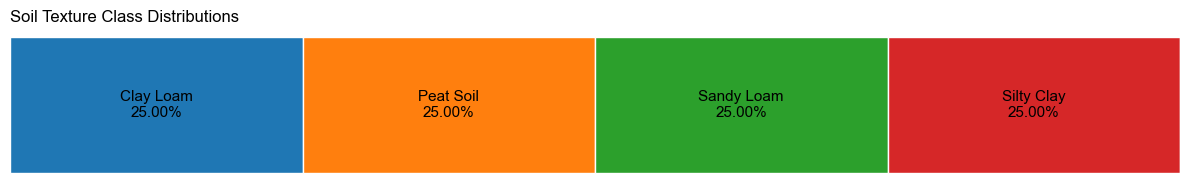

In [31]:
    fig, ax = plt.subplots(figsize=(12, 2))
    data  = _groupby(df, "Soil Texture", "Soil Texture")
    
    total  = data.sum()
    left   = 0
    
    for label, value in data.items():
        width = value / total
        ax.barh(y=0, width=width, left=left, height=0.6, edgecolor='white')
        if width > 0.05:
            ax.text(left + width / 2, 0,
                f'{label}\n{value:,.2f}%',
                ha='center',
                va='center',
                fontsize=11
            )
    
        left += width
    
    ax.set_title("Soil Texture Class Distributions", loc="Left")
    ax.spines[:].set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    
    plt.tight_layout()
    plt.show()

<h1 style='font-family: Bradley Hand ITC; font-size: 25px;  font-weight: 600''>5.0: FEATURES DISTRIBUTIONS | VISUAL EXPLORATORY ANALYSIS</h1>


<h4 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>5.1:  HISTOGRAMS | FREQUENCY DISTRIBUTIONS</h4>

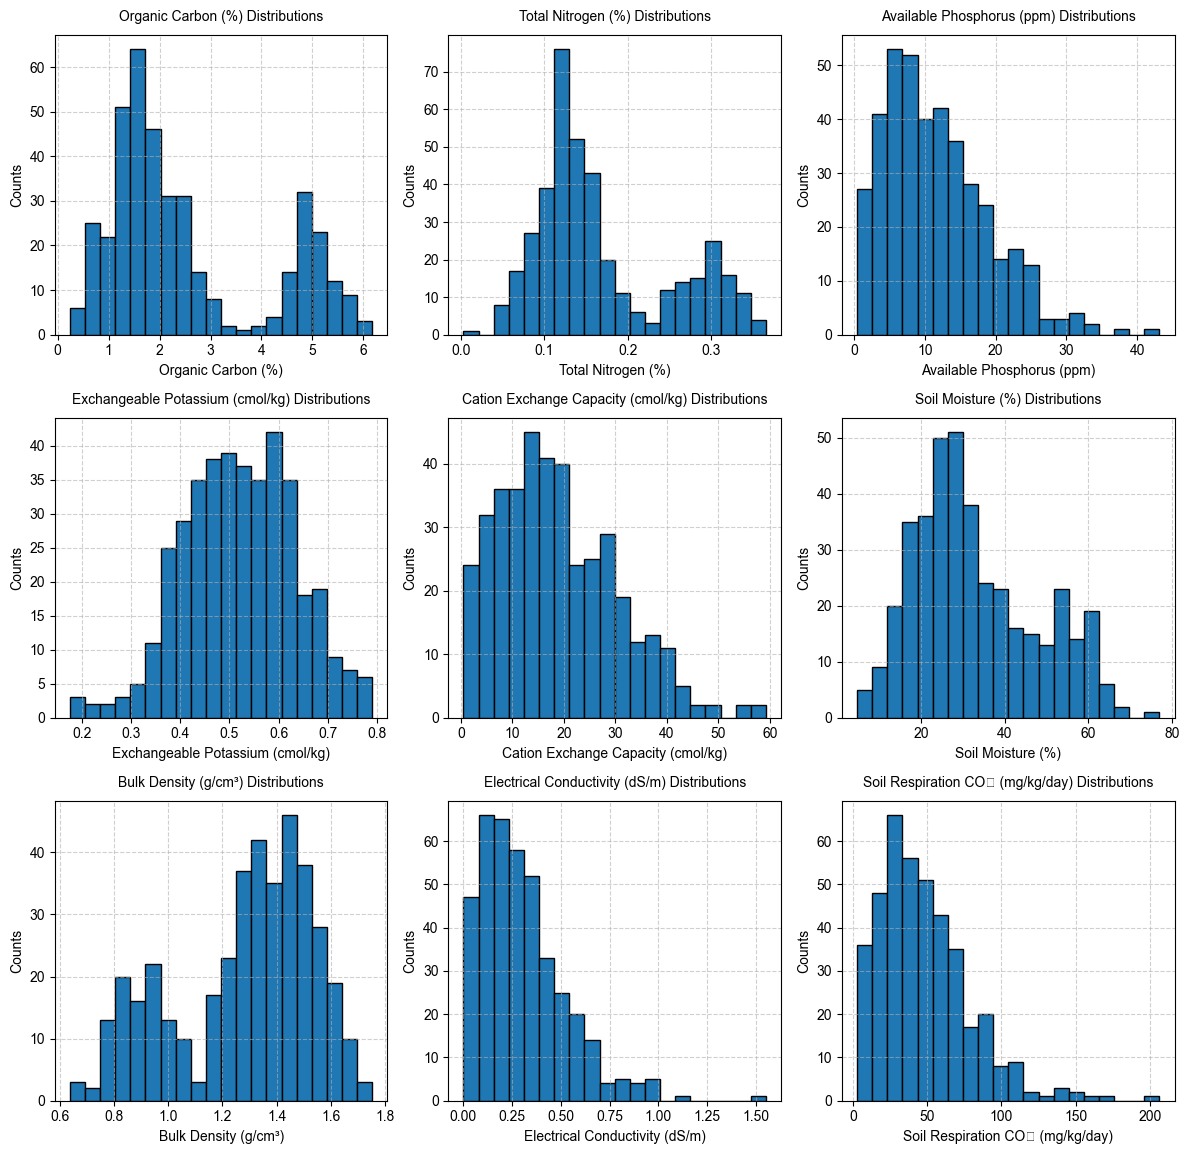

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() 

for idx, column in enumerate(variables[1:]):
    ax = axes[idx]
    n, bins, patches = ax.hist(
                df[column], 
                bins=20, 
                edgecolor='k', 
                )

    ax.set_title(f"{column} Distributions",size=10, pad=10)
    ax.spines[:].set_visible(True)
    ax.grid(linestyle='--', alpha=0.6)
    ax.set_xlabel(column)
    ax.set_ylabel('Counts')
    
for idx in range(len(variables[1:]), len(axes)): fig.delaxes(ax)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h4 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>5.2:  BOXPLOTS | VARIABLES DISTRIBUTIONS</h4>

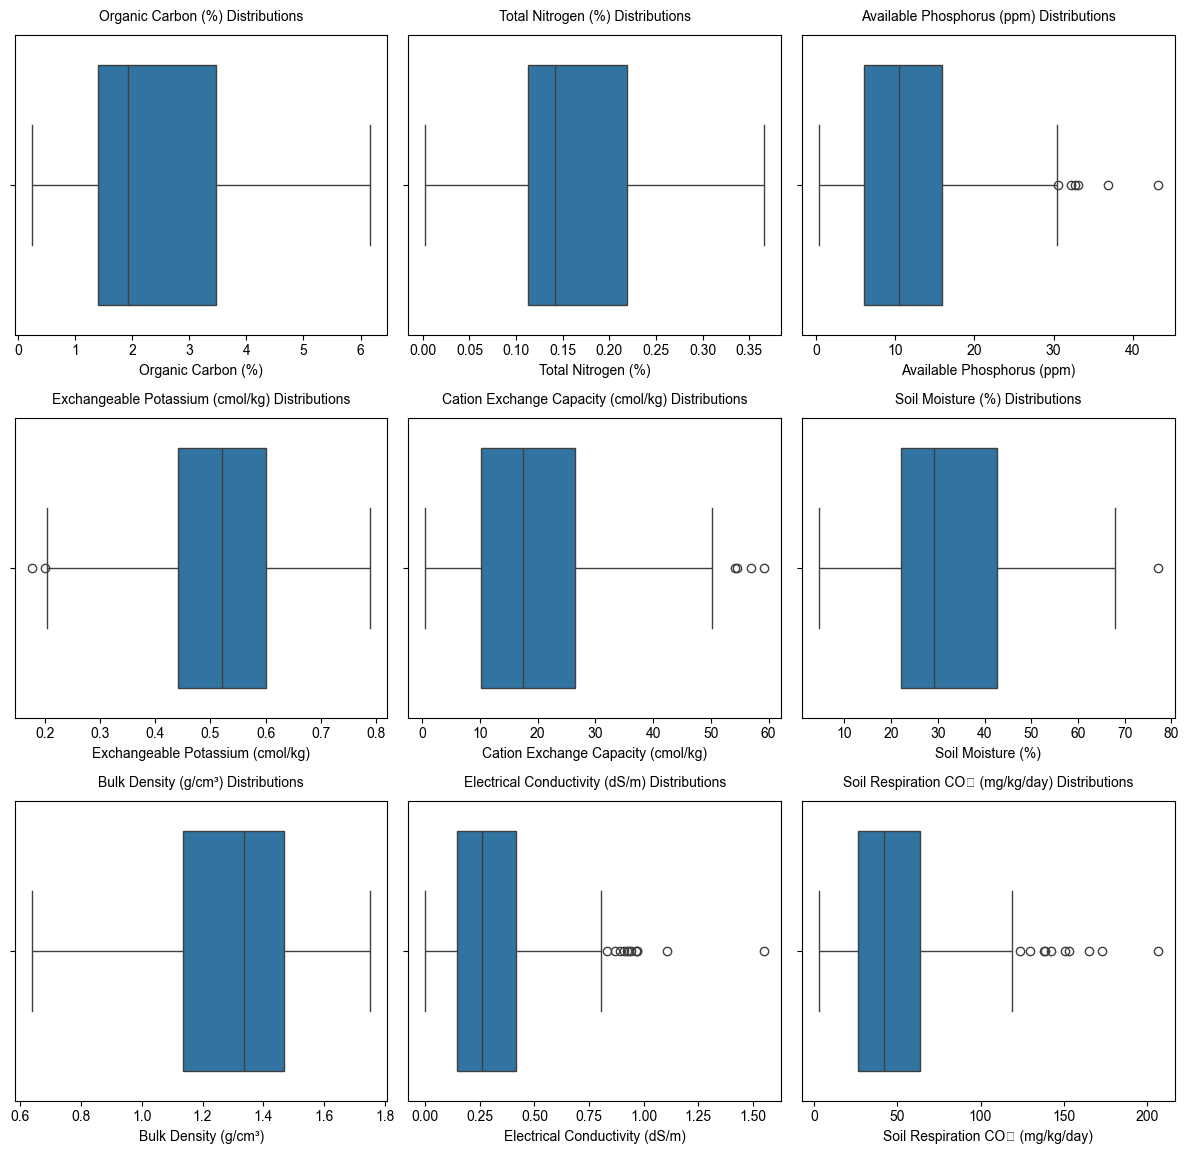

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() 

for idx, column in enumerate(variables[1:]):
    ax = axes[idx]
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(f"{column} Distributions",size=10, pad=10)
    ax.set_xlabel(column)
    ax.set_ylabel('')
    
for idx in range(len(variables[1:]), len(axes)): fig.delaxes(ax)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h4 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>5.4:  BOXPLOTS | VARIABLES DISTRIBUTIONS COMPARISONS</h4>

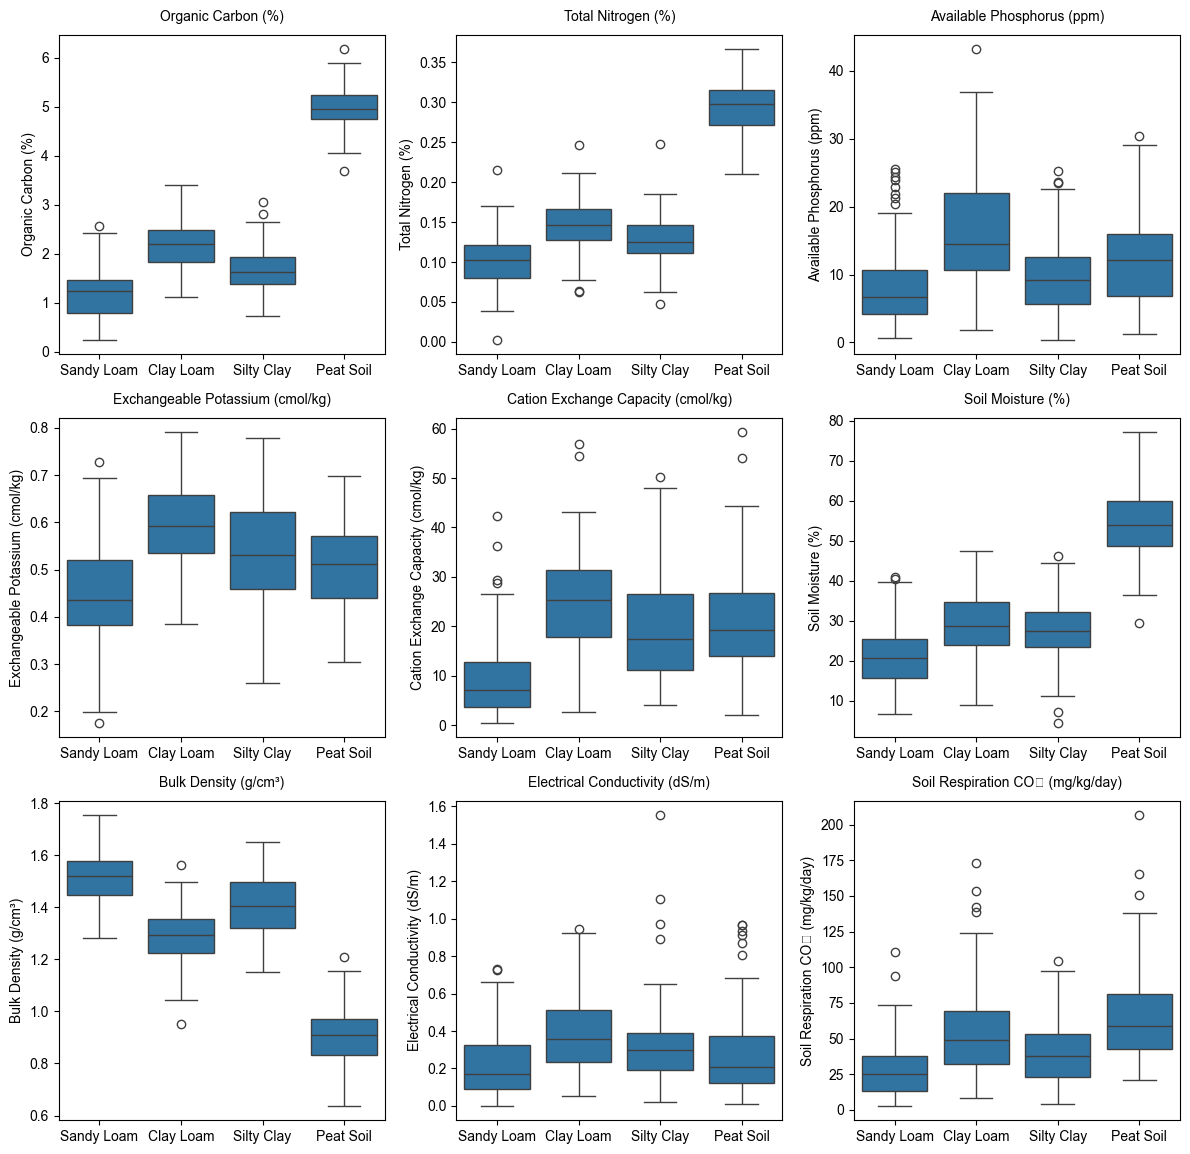

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() 

for idx, column in enumerate(variables[1:]):
    ax = axes[idx]
    sns.boxplot(y=df[column], x=df["Soil Texture"], ax=ax)
    ax.set_title(f"{column}",size=10, pad=10)
    ax.set_ylabel(column)
    ax.set_xlabel('')
    
for idx in range(len(variables[1:]), len(axes)): fig.delaxes(ax)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h4 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>5.5:  VIOLINPLOTS | VARIABLES DISTRIBUTIONS COMPARISONS </h4>

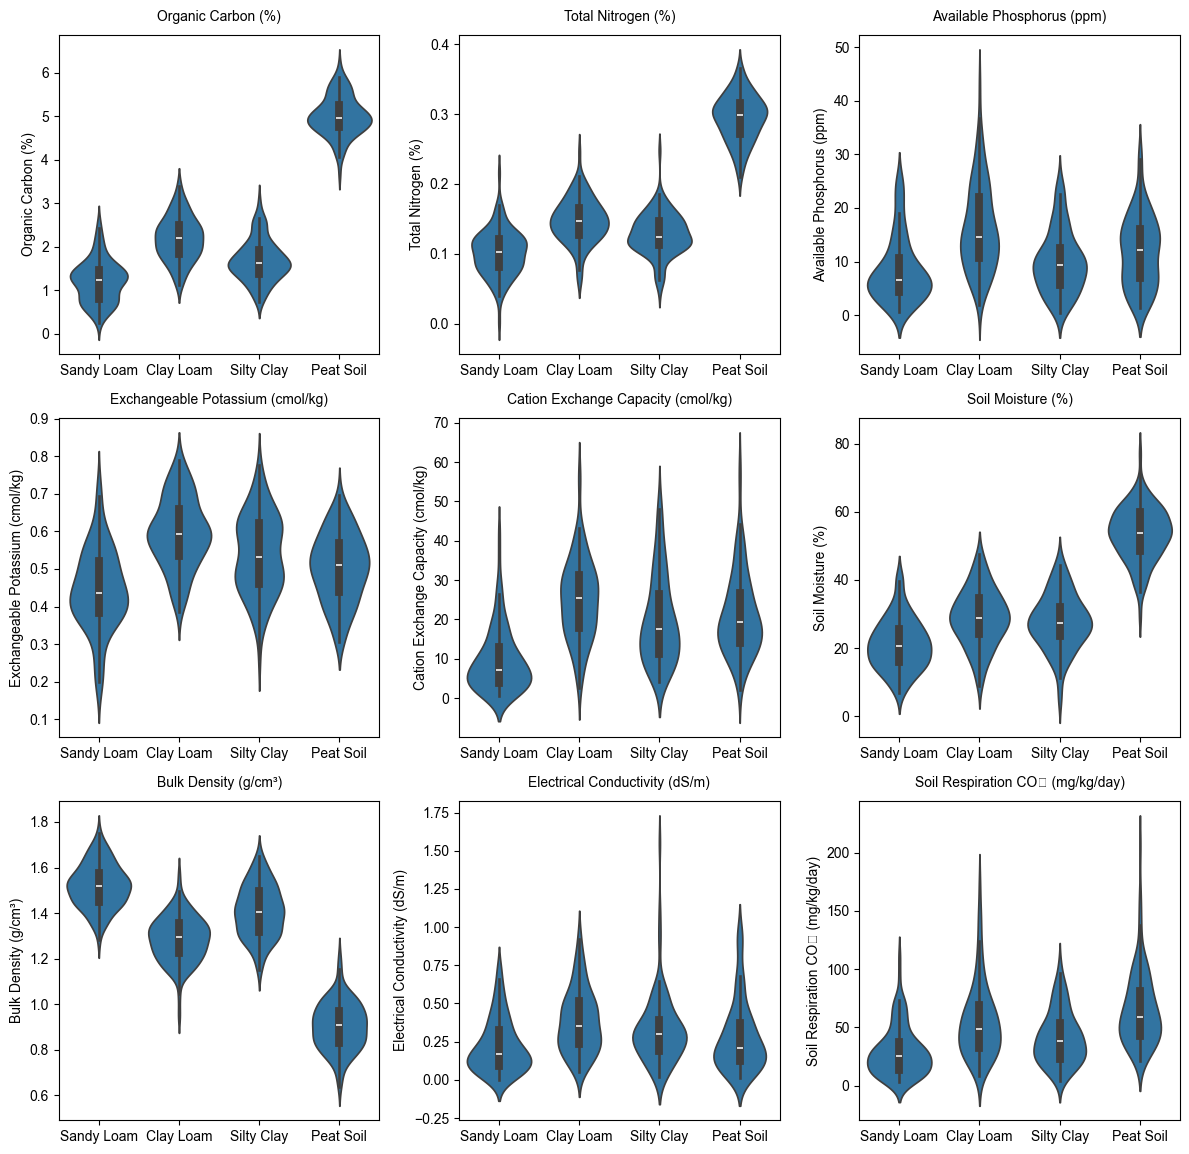

In [95]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() 

for idx, column in enumerate(variables[1:]):
    ax = axes[idx]
    sns.violinplot(y=df[column], x=df["Soil Texture"], ax=ax)
    ax.set_title(f"{column}",size=10, pad=10)
    ax.set_ylabel(column)
    ax.set_xlabel('')
    
for idx in range(len(variables[1:]), len(axes)): fig.delaxes(ax)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h4 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>5.6:  SWAMPLOT | VARIABLES DATA POINTS AND CLUSTERS DISTRIBUTIONS</h4>

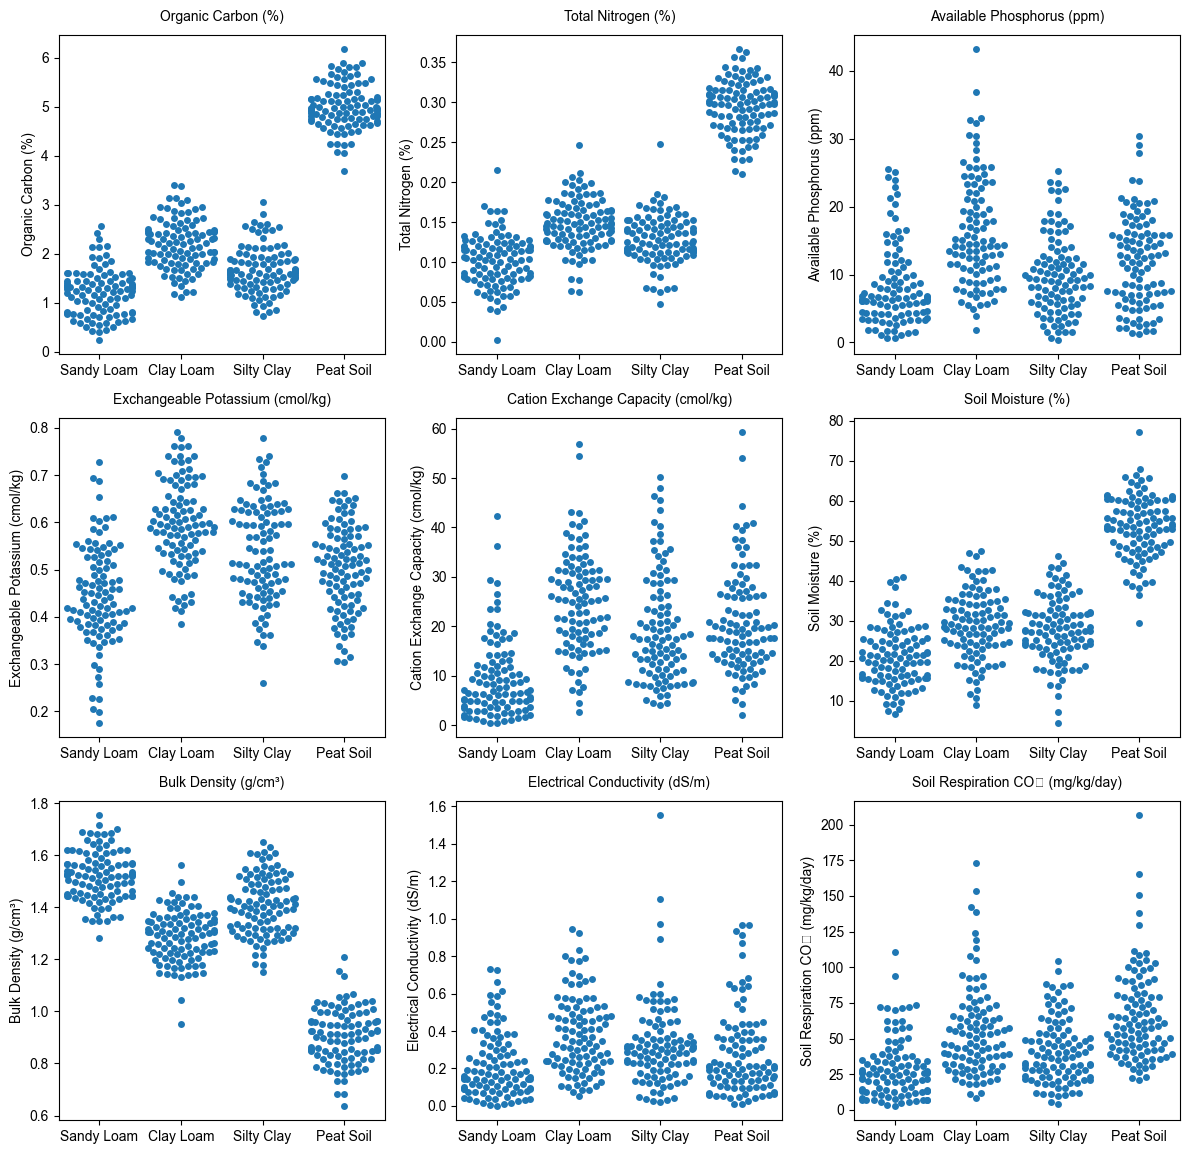

In [171]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() 

for idx, column in enumerate(variables[1:]):
    ax = axes[idx]
    sns.swarmplot(y=df[column], x=df["Soil Texture"], ax=ax)
    ax.set_title(f"{column}",size=10, pad=10)
    ax.set_ylabel(column)
    ax.set_xlabel('')
    
for idx in range(len(variables[1:]), len(axes)): fig.delaxes(ax)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h4 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>5.7:  BARPLOT | VARIABLES MEAN COMPARISONS</h4>

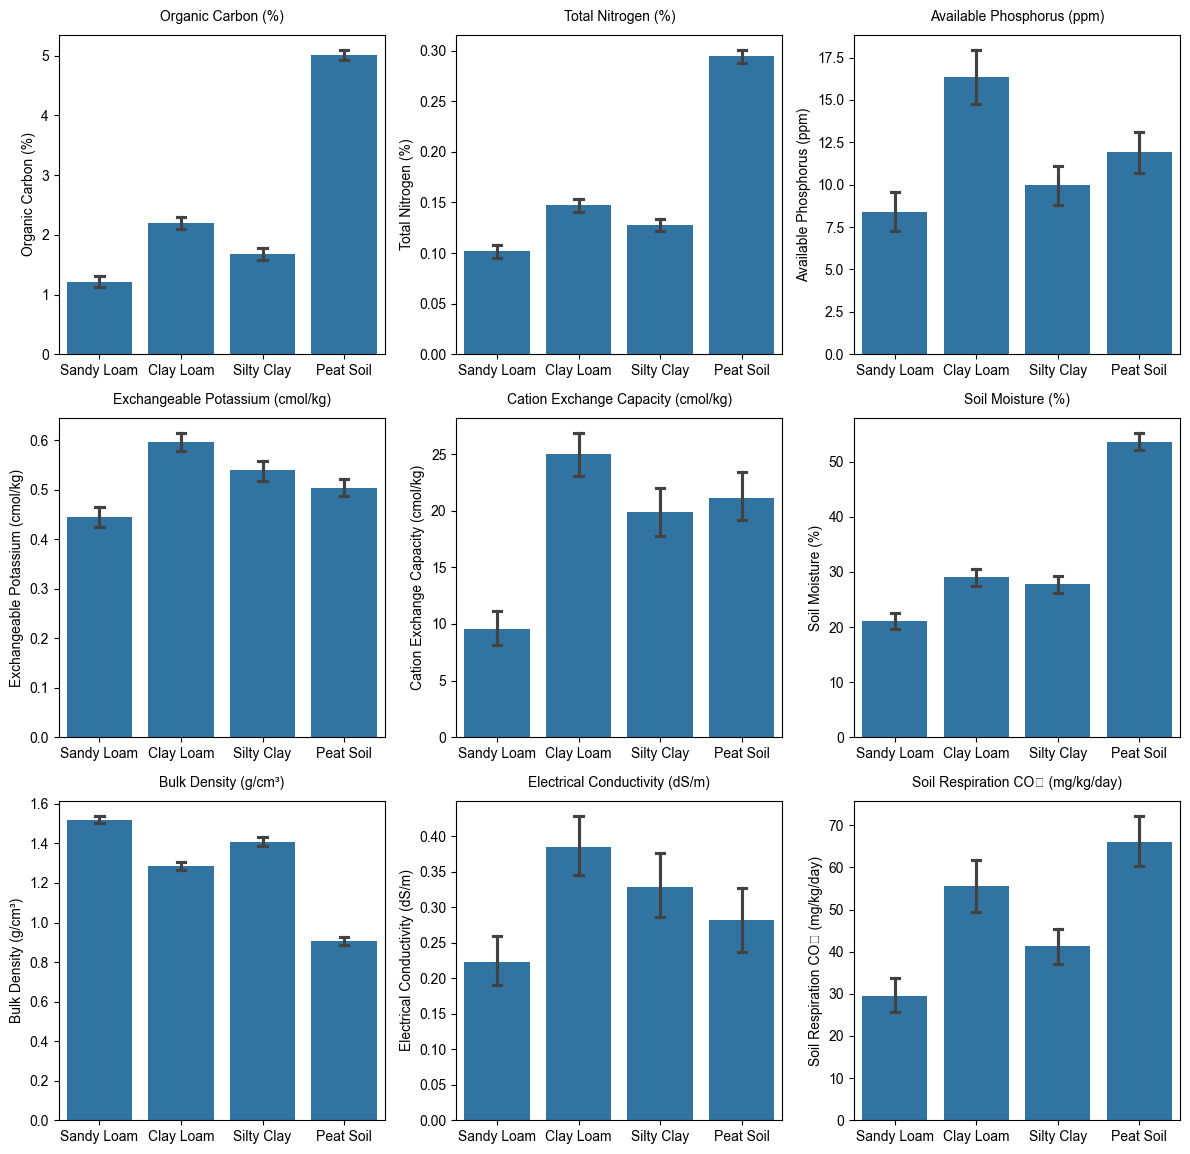

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten() 

for idx, column in enumerate(variables[1:]):
    ax = axes[idx]
    sns.barplot(y=df[column], x=df["Soil Texture"], capsize=0.1, ax=ax)
    ax.set_title(f"{column}",size=10, pad=10)
    ax.set_ylabel(column)
    ax.set_xlabel('')
    
for idx in range(len(variables[1:]), len(axes)): fig.delaxes(ax)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'>6.0:   CORRELATION ANALYSIS | RELATIONSHIP BETWEEN VARIABLES</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>6.1: CORRELATION COEFFICIENTS </h3>

In [40]:
def _corr(df, method="pearson", visualize=True):
    if method not in [
        'pearson', 
        'spearman', 
        'kendall'
        ]: 
        raise ValueError("Invalid method. Choose from 'pearson', 'spearman', or 'kendall'.")
        
    numeric_df  = df.select_dtypes(include=['number'])
    corr_matrix = numeric_df.corr(method=method)
    
    return corr_matrix

correlation_matrix = _corr(df[variables], method="pearson")
print("\n[1/1] CORRELATION COEFFICIENTS CALCULATED SUCCESSFULLY \n")


[1/1] CORRELATION COEFFICIENTS CALCULATED SUCCESSFULLY 



<h3 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'>6.2: CORRELATION COEFFICIENTS HEATMAP </h3>

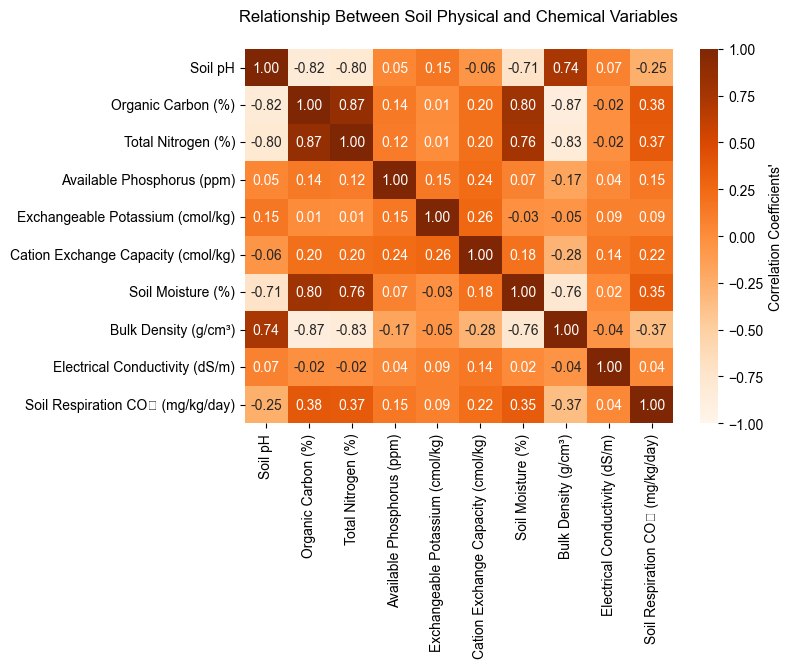

In [41]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
correlation_matrix, 
    annot    =  True, 
    cmap     =  'Oranges', 
    cbar_kws =  {"label": "Correlation Coefficients'"},
    fmt      =  '.2f', 
    vmin     =  -1, 
    vmax     =  1
    )
plt.title("Relationship Between Soil Physical and Chemical Variables", color='k', pad=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>6.3: CORRELATION COEFFICIENTS & STATISTICAL SIGNIFICANCE, STRENGTH AND DIRECTIONS </h3>

In [44]:
def significance_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'
        
def _pearsonr(df: pd.DataFrame, variables: List[str]) -> pd.DataFrame:
    results = []
    for i, variable1 in enumerate(variables):
        for variable2 in variables[i+1:]:
            r_value, p_value  =  pearsonr(df[variable1], df[variable2])
            direction         =  ("Positive" if r_value > 0 else  "Negative" if r_value < 0 else "No correlation")
            p_value_notes     =  ("Significant" if p_value < 0.05 else  "Not Significant")
            strength          =  ("Strong" if abs(r_value) >= 0.7 else "Moderate" if abs(r_value) >= 0.3 else "Weak")
            significance      =  significance_stars(p_value)
            
            results.append({
                'Variable 1':      variable1, 
                'Variable 2':      variable2,
                'Pearson\'s r':    r_value, 
                'p-value':         f"{p_value:.3f}{significance}",
                'Significance':     p_value_notes,
                'Direction':       direction, 
                'Strength':        strength
                })
    
    return pd.DataFrame(results)

results     = _pearsonr(df, variables)
display(results)

,Variable 1,Variable 2,Pearson's r,p-value,Significance,Direction,Strength
0,Soil pH,Organic Carbon (%),-0.82,0.000***,Significant,Negative,Strong
1,Soil pH,Total Nitrogen (%),-0.80,0.000***,Significant,Negative,Strong
2,Soil pH,Available Phosphorus (ppm),0.05,0.321ns,Not Significant,Positive,Weak
3,Soil pH,Exchangeable Potassium (cmol/kg),0.15,0.002**,Significant,Positive,Weak
4,Soil pH,Cation Exchange Capacity (cmol/kg),-0.06,0.221ns,Not Significant,Negative,Weak
5,Soil pH,Soil Moisture (%),-0.71,0.000***,Significant,Negative,Strong
6,Soil pH,Bulk Density (g/cm³),0.74,0.000***,Significant,Positive,Strong
7,Soil pH,Electrical Conductivity (dS/m),0.07,0.143ns,Not Significant,Positive,Weak
8,Soil pH,Soil Respiration CO₂ (mg/kg/day),-0.25,0.000***,Significant,Negative,Weak
9,Organic Carbon (%),Total Nitrogen (%),0.87,0.000***,Significant,Positive,Strong


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>6.4: CORRELATION COEFFICIENTS VISUALIZATIONS </h3>

In [45]:
def compute_correlation_pairs(data: pd.DataFrame)-> pd.DataFrame:
    data["pair"]    =  data["Variable 1"] + " Vs " + data["Variable 2"]
    pairs            =  data.sort_values(by="Pearson's r", ascending=False)
    return pairs

def _sample_highlight(df, n=5): return df["pair"].sample(n=n, random_state=42).tolist()

def _colors(df, highlights, highlight_color="tab:red", default_color="grey"):
    return [highlight_color if pair in highlights else default_color for pair in df["pair"]]

def _correlation_plot(
    df: pd.DataFrame, 
    highlights      = None, 
    figsize         = (9, 12),
    suptitle        =  None,
    highlight_color = "tab:red", 
    default_color   = "grey", 
    segment_width   = 1.5, 
    text_size       = 10, 
    nudge_x         = 0.03
    ):
    
    df               =   df.copy()
    df["highlight"]  =   df["pair"].isin(highlights)
    df["color"]      =   _colors(df, highlights, highlight_color, default_color)
    df               =   df.sort_values("Pearson's r")
    
    fig, ax = plt.subplots(figsize=figsize)

    for _, row in df.iterrows():
        ax.plot(
            [0, row["Pearson's r"]], 
            [row["pair"], row["pair"]],
            color=row["color"], 
            linewidth=segment_width + (0.5 if row["highlight"] else 0)
            )

    ax.scatter(df["Pearson's r"], df["pair"], color=df["color"], zorder=3)
    for _, row in df.iterrows():
        align     = 'right' if row["Pearson's r"] > 0 else 'left'
        x_offset  = -nudge_x if row["Pearson's r"] > 0 else nudge_x
        ax.text(
            x          =  0 + x_offset, 
            y          =  row["pair"], 
            s          =  row["pair"],
            ha         =  align, 
            va         =  'center', 
            color      =  row["color"],
            fontweight =  'bold' if row["highlight"] else 'normal',
            fontsize   =  text_size
            )

    suptitle = ("Relationship Between Variables") if suptitle == None else suptitle
    ax.text(0.25, 0.92, suptitle,
        transform   =  fig.transFigure,
        size        =  14,
        ha          =  'left',
        weight      =  500,
        color       =  "#2c3e50",
        fontfamily  =  'Arial',
        )

    ax.set_xlabel("Correlation Coefficients", size=10, labelpad=10)
    ax.set_ylabel("")
    ax.set_yticks([])
    
    ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
    ax.spines[["left", "right", "top", "bottom"]].set_visible(False)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    return fig, ax

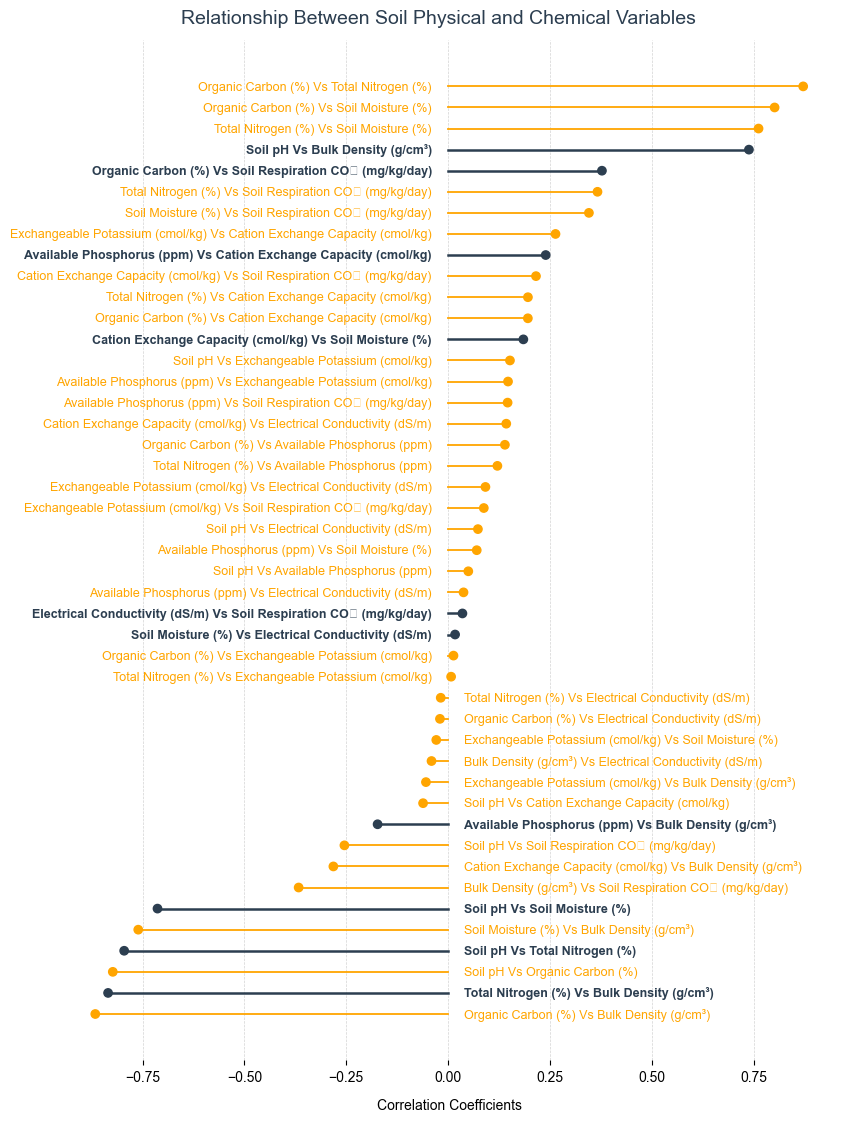

In [46]:
    correlations       =  compute_correlation_pairs(results)
    highlighted_pairs  =  _sample_highlight(correlations, n=10)
    title              =  ("Relationship Between Soil Physical and Chemical Variables")
    
    fig, ax = _correlation_plot(
        correlations,
        suptitle        = title,
        highlights      = highlighted_pairs,
        highlight_color = "#2c3e50",
        default_color   = "orange",
        segment_width   = 1.3,
        text_size       = 9,
        nudge_x         = 0.04
    )

<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'>7.0: FEATURE ENGINEERING AND PREPROCESSING</h1>

<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>7.1:   FEATURE AND TARGERT SELECTION</h2>

In [49]:
features       = df.drop(columns=["Soil Texture"])
target         = df["Soil Texture"]
print("\n[1/1] Features and Targert Defined Successfully\n")


[1/1] Features and Targert Defined Successfully



In [50]:
print("Features: ", features.columns, "\n\nTarget: Soil Texture", target.unique())

Features:  Index(['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
       'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
       'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
       'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
       'Soil Respiration CO₂ (mg/kg/day)'],
      dtype='object') 

Target: Soil Texture ['Sandy Loam' 'Clay Loam' 'Silty Clay' 'Peat Soil']


<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>7.2:  FEATURES SCALING AND LABEL ENCODING</h2>

In [51]:
X             = features.copy()
le            = LabelEncoder()
y             = le.fit_transform(target)
print("Encoded Label: ", y, "\n\n[1/7] Features and Target Defined Successfully\n")

Encoded Label:  [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] 

[1/7] Features and Target Defined Successfully



<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>7.3:  TRAIN-TEST SPLIT</h2>

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
    )

print("\n[2/7] Test and Training Features Splitted Successfully \n")


[2/7] Test and Training Features Splitted Successfully 



<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>7.4: FULL FEATURES PREPROCESSING PIPELINE</h2>

In [54]:
def preprocessor_pipeline(X_train: pd.DataFrame):
    num_cols      = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols      = X_train.select_dtypes(include=["object", "category", "bool"]).columns
    num_pipeline  = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    cat_pipeline  = Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    ))
                    ])
    
    preprocessor = ColumnTransformer([
                    ("num", num_pipeline, num_cols),
                    ("cat", cat_pipeline, cat_cols)
                    ])
    
    return preprocessor

print("\n[3/7] Features Preprocessing Pipeline Created Successfully \n")


[3/7] Features Preprocessing Pipeline Created Successfully 



In [56]:
preprocessor = preprocessor_pipeline(X_train)
display(preprocessor)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


<h1 style='font-family: Bradley Hand ITC; font-size: 25px; font-weight: 600'>8.0: MACHINE LEARNING MODEL DEVELOPMENT</h1>

<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.1: TYPICAL MODEL TRAINING</h2>

In [58]:
model    = Pipeline([("preprocessor", preprocessor), ("model", ExtraTreesClassifier(random_state=42))]) # Pipeline
_        = model.fit(X_train, y_train)
y_pred   = model.predict(X_test)
y_score  = model.predict_proba(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9125


<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.2: MULT-MODEL TRAINING</h2>

In [59]:
def train_models(X_train, y_train, X_test, y_test, models):
    results            = []
    trained_models     = {}

    for name, model in models.items():
        preprocessor = preprocessor_pipeline(X_train)
        pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)

        score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr",  average="macro")
        
        results.append({
            "Model":         name,
            "Accuracy":      accuracy_score(y_test, y_pred),
            "Precision":     precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall":        recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1 Score":      f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "CV Mean":       score.mean(),
            "CV Std":        score.std(),
            "AUC":           auc,
            
            })

        trained_models[name] = pipeline

    report = (pd.DataFrame(results).sort_values(by="Accuracy",ascending=False).reset_index(drop=True) )
    return trained_models, report

In [61]:
models = {
    "Logistic Regression":     LogisticRegression(max_iter=1000),
    "Decision Tree":           DecisionTreeClassifier(random_state=42),
    "Random Forest":           RandomForestClassifier(random_state=42),
    "Extra Trees":             ExtraTreesClassifier(random_state=42),
    "Gradient Boosting":       GradientBoostingClassifier(random_state=42),
    "KNN":                     KNeighborsClassifier(),
    "SVM":                     SVC(probability=True,random_state=42),
    "Naive Bayes":             GaussianNB()
    }

trained_models, report = train_models(X_train, y_train, X_test, y_test, models)
print("\n[1/1] Models Trained Successfully  \n")


[1/1] Models Trained Successfully  



<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.3: MULTIPLE MODEL EVALUATIONS AND COMPARISONS</h2>

In [62]:
display(report)

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,AUC
0,Extra Trees,0.91,0.91,0.91,0.91,0.86,0.03,0.99
1,Gradient Boosting,0.91,0.91,0.91,0.91,0.84,0.03,0.98
2,Naive Bayes,0.90,0.90,0.90,0.90,0.87,0.05,0.98
3,Random Forest,0.90,0.90,0.90,0.90,0.85,0.03,0.98
4,Logistic Regression,0.85,0.85,0.85,0.85,0.90,0.02,0.97
5,Decision Tree,0.84,0.84,0.84,0.83,0.74,0.04,0.89
6,SVM,0.84,0.84,0.84,0.84,0.89,0.03,0.97
7,KNN,0.79,0.78,0.79,0.78,0.84,0.05,0.94


<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.4: BEST MODEL SELECTIONS</h2>


In [64]:
best_model_name      = report.iloc[0]["Model"]
model                = trained_models[best_model_name]
print("Best Model: ", best_model_name,"\n\n", model)

Best Model:  Extra Trees 

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Soil pH', 'Organic Carbon (%)', 'Total Nitrogen (%)',
       'Available Phosphorus (ppm)', 'Exchangeable Potassium (cmol/kg)',
       'Cation Exchange Capacity (cmol/kg)', 'Soil Moisture (%)',
       'Bulk Density (g/cm³)', 'Electrical Conductivity (dS/m)',
       'Soil Respiration CO₂ (mg/kg/day)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                  

In [66]:
prediction           = model.predict(X_test)
print("\n[5/7] The Best Model:", best_model_name, "Accuracy:",  round(report.iloc[0]["Accuracy"], 2))
print("[5/7] The Best Model Predictions:",  le.inverse_transform(prediction))


[5/7] The Best Model: Extra Trees Accuracy: 0.91
[5/7] The Best Model Predictions: ['Sandy Loam' 'Peat Soil' 'Clay Loam' 'Clay Loam' 'Sandy Loam' 'Clay Loam'
 'Sandy Loam' 'Peat Soil' 'Sandy Loam' 'Clay Loam' 'Peat Soil'
 'Silty Clay' 'Silty Clay' 'Peat Soil' 'Sandy Loam' 'Silty Clay'
 'Peat Soil' 'Silty Clay' 'Sandy Loam' 'Sandy Loam' 'Silty Clay'
 'Clay Loam' 'Sandy Loam' 'Peat Soil' 'Peat Soil' 'Sandy Loam' 'Clay Loam'
 'Peat Soil' 'Clay Loam' 'Sandy Loam' 'Clay Loam' 'Peat Soil' 'Clay Loam'
 'Silty Clay' 'Clay Loam' 'Sandy Loam' 'Sandy Loam' 'Peat Soil'
 'Silty Clay' 'Clay Loam' 'Clay Loam' 'Clay Loam' 'Peat Soil' 'Silty Clay'
 'Clay Loam' 'Silty Clay' 'Silty Clay' 'Silty Clay' 'Peat Soil'
 'Silty Clay' 'Sandy Loam' 'Silty Clay' 'Clay Loam' 'Sandy Loam'
 'Silty Clay' 'Sandy Loam' 'Sandy Loam' 'Sandy Loam' 'Sandy Loam'
 'Peat Soil' 'Peat Soil' 'Clay Loam' 'Peat Soil' 'Peat Soil' 'Peat Soil'
 'Peat Soil' 'Clay Loam' 'Silty Clay' 'Clay Loam' 'Sandy Loam'
 'Sandy Loam' 'Clay Loam' 'Cl

<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.5: CONFUSION MATRIXES</h2>

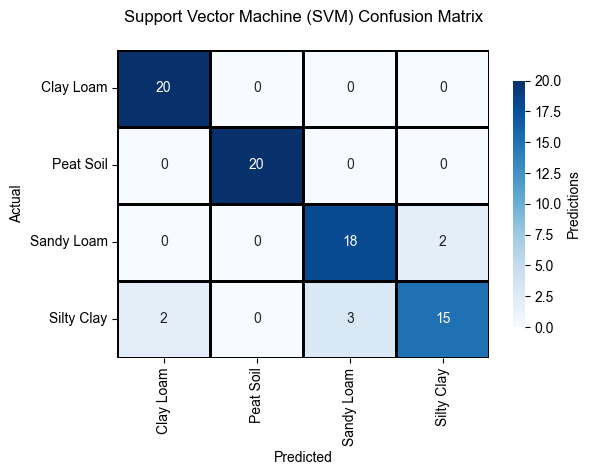

In [67]:
    plt.figure(figsize=(6,4))
    sns.heatmap(
        confusion_matrix(y_test, prediction),
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidth=0.8,
        linecolor="black",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cbar_kws={"label": "Predictions", "shrink": 0.8}
    )
    
    plt.title("Support Vector Machine (SVM) Confusion Matrix", pad=20)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.6: ROC CURVE AND AUC</h2>

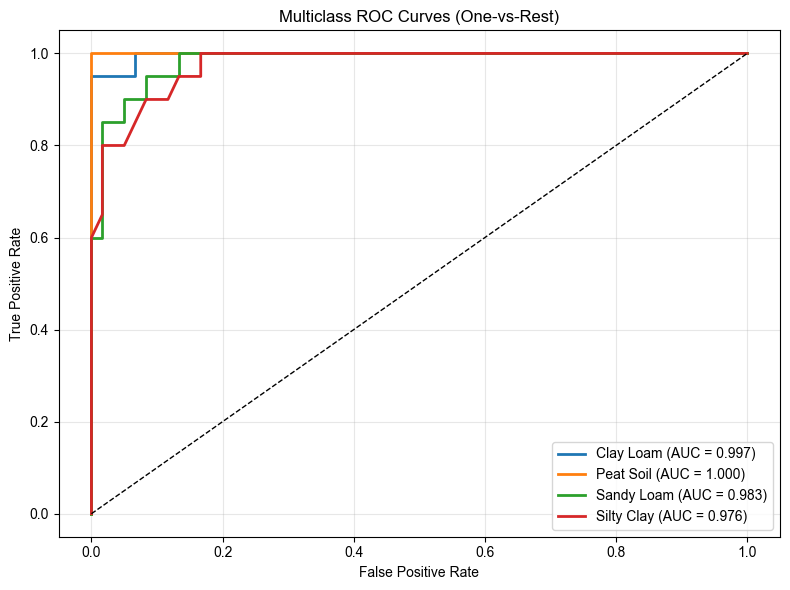

In [69]:
y_score = model.predict_proba(X_test)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("Multiclass ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.7: FEATURES IMPORTANCE</h2>

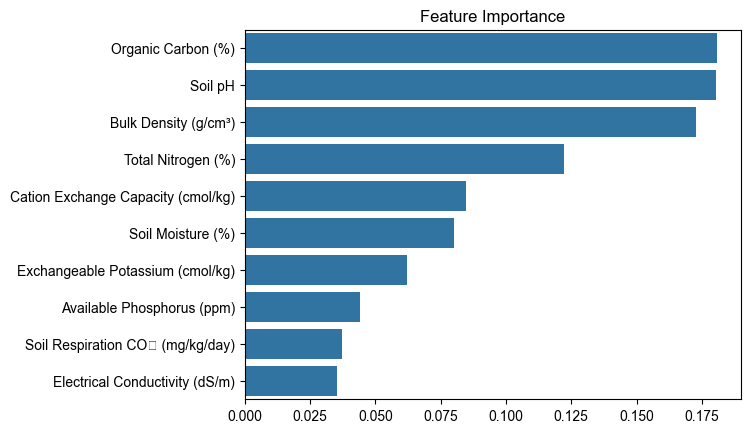

In [70]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

importance   = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_})
importance   = importance.sort_values(by="Importance", ascending=False)
sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance")
plt.xlabel("")
plt.ylabel("")
plt.show()

<h2 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'>8.8: PREDICTION FRPM NEW DATA</h2>

In [93]:
samples                   =  df.sample(15)
test                      =  samples[X_train.columns]
prediction                =  model.predict(test)
samples['Prediction']     =  le.inverse_transform(prediction)
display(samples[samples.columns[6:]].head(15))

,Soil Moisture (%),Bulk Density (g/cm³),Electrical Conductivity (dS/m),Soil Respiration CO₂ (mg/kg/day),Soil Texture,Prediction
203,27.38,1.15,0.26,9.65,Silty Clay,Silty Clay
30,23.04,1.45,0.47,10.39,Sandy Loam,Sandy Loam
29,9.32,1.45,0.25,5.25,Sandy Loam,Sandy Loam
174,41.30,1.17,0.18,31.01,Clay Loam,Clay Loam
275,23.72,1.25,0.89,20.11,Silty Clay,Silty Clay
141,38.43,1.22,0.71,28.97,Clay Loam,Clay Loam
298,21.64,1.30,0.25,40.87,Silty Clay,Silty Clay
229,21.56,1.55,0.46,15.27,Silty Clay,Silty Clay
266,19.92,1.41,0.32,29.32,Silty Clay,Silty Clay
371,53.02,0.92,0.07,73.88,Peat Soil,Peat Soil


<h1 style='text-align: center; font-family: Colonna MT; font-size: 30px; font-weight: 600'><br>Data to Drive Meaningful Insights and Solutions<br>
    <span style="text-align:center; font-family:Arial, sans-serif; font-size:16px; color:#555;">
        <strong>Chausiku Kassimu</strong> |
        Data Analyst | Machine Learning Enthusiast | Python Developer<br>
        📧 <a href="mailto:chausikukassimu1@gmail.com">chausikukassimu1@gmail.com</a>
    </span>
    </h1>
